# Laboratorio 6. Análisis de redes sociales

## 1. Carga, comprensión e integración de los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from collections import Counter
from wordcloud import WordCloud

In [2]:
#1. Carga, comprensión e integración de los datos
print("==== CARGA DE DATOS ====")
videos = pd.read_csv("youtube_videos.csv")
comments = pd.read_csv("youtube_comments.csv")
print("Datos cargados")
print(f" Videos: {len(videos)} registros")
print(f" Comentarios: {len(comments)} registros")

print(f"\nVideos:")
print(" - Informacion general")
print(videos.info())
print(f"\nComentarios:")
print(" - Informacion general")
print(comments.info())

#unidad de observacion, llave primaria y consulta de busqqueda
print("\n==== VIDEOS ====")
print("- Unidad de observacion: Cada fila del archivo 'youtube_videos.csv' representa un video de YouTube")
print("- Llave primaria: video_id (identificador unico del video en YouTube, permite relacionarlo con 'youtube_comments.csv')")
print("- Variables relevantes:\n  + channel_id\n  + channel_name\n  + owner_handler")
print("\n==== COMMENTS ====")
print("- Unidad de observacion: Cada fila del archivo 'youtube_comments.csv' representa un comentario en un video de YouTube")
print("- Llave primaria: comment_id (identificador unico del comentario en YouTube)")
print("- Variables relevantes:\n  + author_channel_id\n  + author_name\n  + author_handle\n  + reply_count\n  + like_count_text")

==== CARGA DE DATOS ====
Datos cargados
 Videos: 293 registros
 Comentarios: 406 registros

Videos:
 - Informacion general
<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   video_id             293 non-null    str  
 1   title                293 non-null    str  
 2   channel_name         293 non-null    str  
 3   channel_id           293 non-null    str  
 4   source_query         293 non-null    str  
 5   source_group         293 non-null    str  
 6   dataset_sources      293 non-null    str  
 7   channel_handle       293 non-null    str  
 8   published_time       280 non-null    str  
 9   view_count_text      280 non-null    str  
 10  description_snippet  268 non-null    str  
 11  video_url            293 non-null    str  
 12  query_hits           293 non-null    str  
 13  keywords             293 non-null    str  
 14  descriptio

### La relacion entre canal, video, autor del comentario, comentario, categoría y consulta de búsqueda.

El canal puede subir videos y cada uno de estos solo le puede pertenecer a un canal (channel_id en videos). Los videos pueden estar varios en la misma categoría, pero un video solo tiene una categoría (category), además puede tener muchos comentarios (pero estos solo pueden pertenecer a un video (video_id en comentarios) de la misma forma que los videos solo pertenecen a un canal).

Los comentarios tienen un solo autor, el cual puede escribir múltiples tanto en el mimso video como en videos diferentes. Y las consultas de búsqueda pueden dar como resultado varios videos (query_hits).

In [3]:
#Integracion
print("Verificacion video_id")
print(f"Videos unicos: {videos['video_id'].nunique()}")
print(f"Comentarios con video_id no nulo: {comments['video_id'].notna().sum()}")

print(f"\nValores nulos videos.video_id: {videos['video_id'].isna().sum()}")
print(f"Valores nulos comentarios.video_id: {comments['video_id'].isna().sum()}")

#merge
df_integrado = comments.merge(
    videos,
    on='video_id',
    how='left',  # LEFT JOIN: conserva todos los comentarios
    suffixes=('_comentario', '_video')  #cols mismo nombre
)

print("\n...Merge completado...")
print(f"Total registros: {len(df_integrado)}")
print(f"Columnas totales: {len(df_integrado.columns)}")


comments_asociados = df_integrado[df_integrado['title'].notna()]
comments_no_asociados = df_integrado[df_integrado['title'].isna()]#video no encontrado

print(f"\nTotal comentarios: {len(comments)}")
print(f"Comentarios asociados a un video: {len(comments_asociados)}")
print(f"Comentarios no asociados: {len(comments_no_asociados)}")
print(f"Tasa asociacion: {len(comments_asociados)/len(comments)*100:.2f}%")

Verificacion video_id
Videos unicos: 293
Comentarios con video_id no nulo: 406

Valores nulos videos.video_id: 0
Valores nulos comentarios.video_id: 0

...Merge completado...
Total registros: 406
Columnas totales: 36

Total comentarios: 406
Comentarios asociados a un video: 406
Comentarios no asociados: 0
Tasa asociacion: 100.00%


## 2. Calidad, limpieza y preprocesamiento

In [4]:
#diagnostico calidad
print("==== DIMENSIONES Y TIPOS DE VARIABLES ====")
print(f"Videos: {videos.shape[0]} filas, {videos.shape[1]} columnas")
print(f"Comentarios: {comments.shape[0]} filas, {comments.shape[1]} columnas")

print("\n- Tipos variables (Videos)")
print(videos.dtypes.value_counts())

print("\n- Tipos variables (Comentarios)")
print(comments.dtypes.value_counts())

print("\n---VALORES FALTANTES ----")
print("- Videos:")
missing_videos = videos.isnull().sum()
missing_videos = missing_videos[missing_videos > 0].sort_values(ascending=False)
if len(missing_videos) > 0:
    print(missing_videos)
    print(f"Total valores faltantes: {missing_videos.sum()}")
else:
    print("Sin valores faltantes")

print("\n- Comentarios:")
missing_comments = comments.isnull().sum()
missing_comments = missing_comments[missing_comments > 0].sort_values(ascending=False)
if len(missing_comments) > 0:
    print(missing_comments)
    print(f"Total valores faltantes: {missing_comments.sum()}")
else:
    print("Sin valores faltantes")


print("\n--- REGISTROS DUPLICADOS ---")
print(f"Videos duplicados (por video_id): {videos['video_id'].duplicated().sum()}")
print(f"Comentarios duplicados (por comment_id): {comments['comment_id'].duplicated().sum()}")
print(f"Comentarios duplicados (por todas las columnas): {comments.duplicated().sum()}")

print("\n--- VARIABLES CONSTANTES ---")
print("- Videos:")
for col in videos.columns:
    if videos[col].nunique() == 1:
        print(f"  {col}: valor unico ({videos[col].iloc[0]})") #si no hsale no hay

print("\n- Comentarios:")
for col in comments.columns:
    if comments[col].nunique() == 1:
        print(f"  {col}: valor único ({comments[col].iloc[0]})")

#Outliers
print("\n--- VALORES ATIPICOS (view_count) ---")
print(videos['view_count'].describe())

Q1 = videos['view_count'].quantile(0.25)
Q3 = videos['view_count'].quantile(0.75)
IQR = Q3 - Q1
outliers = videos[(videos['view_count'] < Q1 - 1.5*IQR) | (videos['view_count'] > Q3 + 1.5*IQR)]
print(f"\nOutliers view_count: {len(outliers)} ({len(outliers)/len(videos)*100:.2f}%)")

print("\n--- CONSISTENCIA ENTRE IDENTIFICADORES ---") #handersl = ids
print("\n- Videos:")
channel_id_handle_match = (videos['channel_id'].notna() & videos['channel_handle'].notna()).sum()
print(f"Registros con channel_id y channel_handle: {channel_id_handle_match}")

print("\n- Comentarios:")
author_id_handle_match = (comments['author_channel_id'].notna() & comments['author_handle'].notna()).sum()
print(f"Registros con author_channel_id y author_handle: {author_id_handle_match}")

print("\n--- Consistencia owner_handle vs channel_handle ---")
owner_channel_match = (videos['owner_handle'] == videos['channel_handle']).sum()
print(f"Registros donde owner_handle == channel_handle: {owner_channel_match}/{len(videos)}")

==== DIMENSIONES Y TIPOS DE VARIABLES ====
Videos: 293 filas, 20 columnas
Comentarios: 406 filas, 17 columnas

- Tipos variables (Videos)
str      19
int64     1
Name: count, dtype: int64

- Tipos variables (Comentarios)
str        14
int64       1
bool        1
float64     1
Name: count, dtype: int64

---VALORES FALTANTES ----
- Videos:
description            26
description_snippet    25
published_time         13
view_count_text        13
dtype: int64
Total valores faltantes: 77

- Comentarios:
viewer_rating    406
dtype: int64
Total valores faltantes: 406

--- REGISTROS DUPLICADOS ---
Videos duplicados (por video_id): 0
Comentarios duplicados (por comment_id): 0
Comentarios duplicados (por todas las columnas): 0

--- VARIABLES CONSTANTES ---
- Videos:

- Comentarios:
  is_pinned: valor único (False)

--- VALORES ATIPICOS (view_count) ---
count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.46500

#### Variables problematicas
- Videos:

> 1. published_time: el texto es relativo, puede ser reemplazado por 'publish_date'
2. view_count_text: texto, datos ya en 'view_count', se puede reemplazar
3. description_snippet: fragmento descripción, no puede analizarse mucho, eliminar
4. upload_date: redundante con 'publish_date', eliminar
5. owner_handle: reemplazable con 'channel_handle'


- Comentarios:


> 1. is_pinned: constante False, no da mucho aporte realmente al ser pinneados por criterios varios.
2. viewer_rating: valores completamente vacíos, eliminar
3. video_title, channel_name, channel_id: redundantes por estar ya en videos, eliminar (la integracion ya lo incluye)
5. published_text: Texto relativo, eliminar
6. like_count_text: necesita limpieza, convertir a numerico









In [5]:
#normalizar
print("=== NORMALIZACION ===")
videos_clean = videos.copy()
comments_clean = comments.copy()

#ids strings
videos_clean['video_id'] = videos_clean['video_id'].astype(str)
videos_clean['channel_id'] = videos_clean['channel_id'].astype(str)
comments_clean['video_id'] = comments_clean['video_id'].astype(str)
comments_clean['comment_id'] = comments_clean['comment_id'].astype(str)
comments_clean['author_channel_id'] = comments_clean['author_channel_id'].astype(str)

#eliminar dups
videos_clean = videos_clean.drop_duplicates(subset=['video_id'])
comments_clean = comments_clean.drop_duplicates(subset=['comment_id'])

print(f"- Videos sin duplicados: {len(videos_clean)}")
print(f"- Comentarios sin duplicados: {len(comments_clean)}")

#limpieza espacios y caracterses
for col in ['video_id', 'channel_id']:
    videos_clean[col] = videos_clean[col].str.strip()

for col in ['video_id', 'comment_id', 'author_channel_id']:
    comments_clean[col] = comments_clean[col].str.strip()

print("\nIdentificadores normalizados")


print("\n--- CONVERSION A NUMERICO ---")
def convertir_like_count(valor):
    """
    Convierte like_count_text a entero.
    Maneja: "1,234", "1.2K", "2.3M", "N/A", valores vacíos
    """
    if pd.isna(valor) or valor == '' or valor == 'N/A':
        return 0

    valor = str(valor).strip()
    valor = valor.replace('vistas', '').replace('likes', '').strip()
    #K (miles)
    if 'K' in valor:
        valor = valor.replace('K', '').strip()
        try:
            return int(float(valor) * 1000)
        except:
            return 0
    #M (millones)
    if 'M' in valor:
        valor = valor.replace('M', '').strip()
        try:
            return int(float(valor) * 1000000)
        except:
            return 0

    valor = valor.replace(',', '').strip()
    try:
        return int(float(valor))
    except:
        return 0

comments_clean['like_count'] = comments_clean['like_count_text'].apply(convertir_like_count)

print("...like_count_text convertido...")


if 'view_count_text' in videos_clean.columns:
    print("\nConsistencia view_count vs view_count_text:")
    if videos_clean['view_count_text'].dtype == 'object':
        def extraer_numero(texto):
            if pd.isna(texto):
                return None
            import re
            numeros = re.findall(r'[\d,]+', str(texto))
            if numeros:
                return int(numeros[0].replace(',', ''))
            return None

        videos_clean['view_count_from_text'] = videos_clean['view_count_text'].apply(extraer_numero)
        comparacion = (videos_clean['view_count'] == videos_clean['view_count_from_text']).sum()
        print(f"  {comparacion}/{len(videos_clean)}")

print("\n=== LIMPIEZA TEXTO ===")
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
#stopwords español
stopwords_es = set(stopwords.words('spanish'))
stopwords_es.update(['y', 'e', 'o', 'u', 'q', 'x', 'k', 'w'])

#stemmer español
stemmer = SnowballStemmer('spanish')

def limpiar_texto(texto, stem=False):
    if pd.isna(texto):
        return ""

    texto = str(texto)

    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    texto = re.sub(r'@\w+', ' ', texto) #menciones (@usuario)
    texto = re.sub(r'#\w+', ' ', texto) #hashtags (#tema)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stopwords_es]

    if stem:
        palabras = [stemmer.stem(p) for p in palabras]

    return ' '.join(palabras)

print("\n...Procesando textos de videos...")
#og
videos_clean['title_original'] = videos_clean['title']
videos_clean['description_original'] = videos_clean['description'].fillna('')
#post limpieza
videos_clean['title_limpio'] = videos_clean['title'].apply(limpiar_texto)
videos_clean['description_limpio'] = videos_clean['description'].fillna('').apply(limpiar_texto)
print("Limpieza de videos completada")

print("\n...Procesando textos de comentarios...")
#og
comments_clean['text_original'] = comments_clean['text']
#post limpieza
comments_clean['text_limpio'] = comments_clean['text'].apply(lambda x: limpiar_texto(x, stem=False))
comments_clean['text_stemmed'] = comments_clean['text'].apply(lambda x: limpiar_texto(x, stem=True))

print("Limpieza de comentarios completada")

#cuantificacion
print("=== CUANTIFICACION EFECTO LIMPIEZA ===")

print("\n--- REGISTROS MODIFICADOS  ---")
#videos
vacios_title_original = videos_clean['title'].isna().sum()
vacios_title_limpio = (videos_clean['title_limpio'] == '').sum()
print("- Videos")
print(f"   Titulos vacios originales: {vacios_title_original}")
print(f"   Titulos vacios post limpieza: {vacios_title_limpio}")
vacios_desc_original = videos_clean['description'].isna().sum()
vacios_desc_limpio = (videos_clean['description_limpio'] == '').sum()
print(f"   Descripciones vacias originales: {vacios_desc_original}")
print(f"   Descripciones vacias post limpieza: {vacios_desc_limpio}")
#comentarios
print("- Comentarios")
vacios_comment_original = (comments_clean['text_original'] == '').sum()
vacios_comment_limpio = (comments_clean['text_limpio'] == '').sum()
print(f"   Textos vacios originales: {vacios_comment_original}")
print(f"   Textos vacios post limpieza: {vacios_comment_limpio}")

#tamaños
print("\n--- TAMAÑO PROMEDIO DE TEXTOS (caracteres) ---")
print("- Titulos")
print(f"   Original: {videos_clean['title'].str.len().mean():.2f}")
print(f"   Limpio: {videos_clean['title_limpio'].str.len().mean():.2f}")
print("- Descripciones")
print(f"   Original: {videos_clean['description'].fillna('').str.len().mean():.2f}")
print(f"   Limpio: {videos_clean['description_limpio'].str.len().mean():.2f}")
print("- Comentarios")
print(f"   Original: {comments_clean['text_original'].str.len().mean():.2f}")
print(f"   Limpio: {comments_clean['text_limpio'].str.len().mean():.2f}")

#redcicon
print("\n--- REDUCCION TAMAÑO ---")
reduccion_titulos = (1 - videos_clean['title_limpio'].str.len().mean() / videos_clean['title'].str.len().mean()) * 100
reduccion_desc = (1 - videos_clean['description_limpio'].str.len().mean() / videos_clean['description'].fillna('').str.len().mean()) * 100
reduccion_comments = (1 - comments_clean['text_limpio'].str.len().mean() / comments_clean['text_original'].str.len().mean()) * 100

print(f"Titulos: {reduccion_titulos:.2f}% reduccion")
print(f"Descripciones: {reduccion_desc:.2f}% reduccion")
print(f"Comentarios: {reduccion_comments:.2f}% reduccion")

# num prom tokesn
print("\n--- NO. DE TOKENS PROMEDIO ---")
def contar_palabras(texto):
    if pd.isna(texto):
        return 0
    return len(str(texto).split())

videos_clean['tokens_title_orig'] = videos_clean['title'].apply(contar_palabras)
videos_clean['tokens_title_clean'] = videos_clean['title_limpio'].apply(contar_palabras)

comments_clean['tokens_comment_orig'] = comments_clean['text_original'].apply(contar_palabras)
comments_clean['tokens_comment_clean'] = comments_clean['text_limpio'].apply(contar_palabras)
print("- Titulos")
print(f"   Original: {videos_clean['tokens_title_orig'].mean():.2f} palabras")
print(f"   Limpio: {videos_clean['tokens_title_clean'].mean():.2f} palabras")
print("- Comentarios")
print(f"   Original: {comments_clean['tokens_comment_orig'].mean():.2f} palabras")
print(f"   Limpio: {comments_clean['tokens_comment_clean'].mean():.2f} palabras")

#dups
print("\n--- DUPLICADOS ---")
print("- Videos:")
print(f"   Titulos originales duplicados: {videos_clean['title'].duplicated().sum()}")
print(f"   Titulos limpios duplicados: {videos_clean['title_limpio'].duplicated().sum()}")

print("- Comentarios:")
print(f"   Textos originales duplicados: {comments_clean['text_original'].duplicated().sum()}")
print(f"   Textos limpios duplicados: {comments_clean['text_limpio'].duplicated().sum()}")

=== NORMALIZACION ===
- Videos sin duplicados: 293
- Comentarios sin duplicados: 406

Identificadores normalizados

--- CONVERSION A NUMERICO ---
...like_count_text convertido...

Consistencia view_count vs view_count_text:

=== LIMPIEZA TEXTO ===

...Procesando textos de videos...
Limpieza de videos completada

...Procesando textos de comentarios...
Limpieza de comentarios completada
=== CUANTIFICACION EFECTO LIMPIEZA ===

--- REGISTROS MODIFICADOS  ---
- Videos
   Titulos vacios originales: 0
   Titulos vacios post limpieza: 3
   Descripciones vacias originales: 26
   Descripciones vacias post limpieza: 28
- Comentarios
   Textos vacios originales: 0
   Textos vacios post limpieza: 6

--- TAMAÑO PROMEDIO DE TEXTOS (caracteres) ---
- Titulos
   Original: 60.45
   Limpio: 44.28
- Descripciones
   Original: 427.50
   Limpio: 255.88
- Comentarios
   Original: 139.24
   Limpio: 91.25

--- REDUCCION TAMAÑO ---
Titulos: 26.75% reduccion
Descripciones: 40.15% reduccion
Comentarios: 34.46% re

## 3. Análisis exploratorio

In [6]:
print("=== ANALISIS EXPLORATORIO ===")
print(f"- Total videos: {len(videos_clean)}")
print(f"- Total comentarios: {len(comments_clean)}")
print(f"- Canales unicos: {videos_clean['channel_id'].nunique()}")
print(f"- Autores unicos: {comments_clean['author_channel_id'].nunique()}")

vids_channel = videos_clean.groupby('channel_name').size().sort_values(ascending=False)
print(f"\n--- Videos por canal (Top 5) --- \n{vids_channel.head(5)}\n")
comms_vid = comments_clean.groupby('video_id').size().sort_values(ascending=False)
print(f"\n--- Comentarios por video (Top 5) --- \n{comms_vid.head(5)}\n")
auths_vid = comments_clean.groupby('video_id')['author_channel_id'].nunique().sort_values(ascending=False)
print(f"\n--- Autores unicos por canal (Top 5) --- \n{auths_vid.head(5)}\n")

#visualizaciones, resputesas, likes, categorias y bsuquedas
print("--- DESCRIPCIONES ---")
print(f"Visualizaciones:\n{videos_clean['view_count'].describe()}\n")
print(f"Respuestas:\n{comments_clean['reply_count'].describe()}\n")
print(f"Likes:\n{comments_clean['like_count'].describe()}\n")
print(f"Categorias:\n{videos_clean['category'].value_counts()}\n")
print(f"Busquedas:\n{videos_clean['source_query'].value_counts().head(10)}\n")


print("\n--- CONCENTRACION DE PARTICIPACION ---")
comentarios_ordenados = comms_vid.sort_values(ascending=False)
comentarios_acumulados = comentarios_ordenados.cumsum()
proporcion_top20 = comentarios_acumulados.iloc[:20] / comentarios_acumulados.iloc[-1] * 100

print(f"Top 10 videos concentran: {proporcion_top20.iloc[9]:.2f}% de los comentarios")

comms_ch = comments_clean.groupby('channel_id').size().sort_values(ascending=False)
comentarios_canal_acum = comms_ch.cumsum()
prop_canal_top5 = comentarios_canal_acum.iloc[:5] / comentarios_canal_acum.iloc[-1] * 100
print(f"Top 5 canales concentran: {prop_canal_top5.iloc[4]:.2f}% de los comentarios")


=== ANALISIS EXPLORATORIO ===
- Total videos: 293
- Total comentarios: 406
- Canales unicos: 97
- Autores unicos: 332

--- Videos por canal (Top 5) --- 
channel_name
Gobierno de la República de Guatemala    32
Municipalidad de Guatemala               27
Quorum                                   18
PrensaLibreOficial                       17
Ministerio de Gobernación                14
dtype: int64


--- Comentarios por video (Top 5) --- 
video_id
n8iP75gIpmw    161
j43HgwYFKfk     50
6W4u8sGEnGM     45
OkXlHx0hx-8     25
PjmxCj-a9Hg     25
dtype: int64


--- Autores unicos por canal (Top 5) --- 
video_id
n8iP75gIpmw    128
j43HgwYFKfk     49
6W4u8sGEnGM     32
lj983NWyAQY     25
PjmxCj-a9Hg     19
Name: author_channel_id, dtype: int64

--- DESCRIPCIONES ---
Visualizaciones:
count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64

Respues

In [7]:
# Hashtags
print("=== HASHTAGS ===")
import re

def extraer_hashtags(texto):
    if pd.isna(texto):
        return []
    return re.findall(r'#(\w+)', str(texto))

# Hashtags en comentarios
hashtags_comments = []
for t in comments_clean['text_original']:
    hashtags_comments.extend(extraer_hashtags(t))

# Hashtags en descripciones de videos
hashtags_videos = []
for t in videos_clean['description'].fillna(''):
    hashtags_videos.extend(extraer_hashtags(t))

print(f"Hashtags en comentarios: {len(hashtags_comments)}")
print(f"Hashtags unicos en comentarios: {len(set(hashtags_comments))}")
if hashtags_comments:
    from collections import Counter
    top_ht = Counter(hashtags_comments).most_common(10)
    print("Top 10 hashtags en comentarios:")
    for ht, count in top_ht:
        print(f"  #{ht}: {count}")

print(f"\nHashtags en descripciones: {len(hashtags_videos)}")
print(f"Hashtags unicos en descripciones: {len(set(hashtags_videos))}")
if hashtags_videos:
    top_ht_v = Counter(hashtags_videos).most_common(10)
    print("Top 10 hashtags en descripciones:")
    for ht, count in top_ht_v:
        print(f"  #{ht}: {count}")

# Bigramas frecuentes
print("\n=== BIGRAMAS FRECUENTES ===")
from nltk import bigrams
from nltk.tokenize import word_tokenize

# Bigramas en comentarios limpios
todos_comentarios = ' '.join(comments_clean['text_limpio'].dropna())
tokens = todos_comentarios.split()
bigr = list(bigrams(tokens))
bigram_freq = Counter(bigr).most_common(15)
print("Top 15 bigramas en comentarios:")
for (p1, p2), count in bigram_freq:
    print(f"  '{p1} {p2}': {count}")

# Bigramas en titulos de videos
todos_titulos = ' '.join(videos_clean['title_limpio'].dropna())
tokens_t = todos_titulos.split()
bigr_t = list(bigrams(tokens_t))
bigram_freq_t = Counter(bigr_t).most_common(10)
print("\nTop 10 bigramas en titulos:")
for (p1, p2), count in bigram_freq_t:
    print(f"  '{p1} {p2}': {count}")


=== HASHTAGS ===
Hashtags en comentarios: 1
Hashtags unicos en comentarios: 1
Top 10 hashtags en comentarios:
  #IneptoBran: 1

Hashtags en descripciones: 547
Hashtags unicos en descripciones: 347
Top 10 hashtags en descripciones:
  #Guatemala: 29
  #guatemala: 19
  #noticias: 14
  #LaRondaGt: 8
  #nacionales: 7
  #like: 7
  #comenta: 7
  #comparte: 7
  #siguenos: 7
  #LaRondaGT: 7

=== BIGRAMAS FRECUENTES ===
Top 15 bigramas en comentarios:
  'presidente bernardo': 9
  'bernardo arevalo': 8
  'ciudad guatemala': 6
  'nery rodas': 5
  'bla bla': 5
  'pacto corruptos': 5
  'viva guatemala': 4
  'busquen trabajo': 4
  'ser diputados': 4
  'lleva años': 4
  'dinero pueblo': 4
  'comida nadie': 4
  'guatemala saludos': 4
  'muriendo hambre': 4
  'hand purple': 3

Top 10 bigramas en titulos:
  'conferencia prensa': 26
  'gobierno guatemala': 26
  'prensa gobierno': 24
  'municipalidad guatemala': 18
  'ciudad guatemala': 9
  'guatemala conferencia': 7
  'nacional civil': 6
  'bernardo aréva

=== POPULARIDAD VS PARTICIPACION ===
Correlacion visualizaciones vs comentarios: -0.01


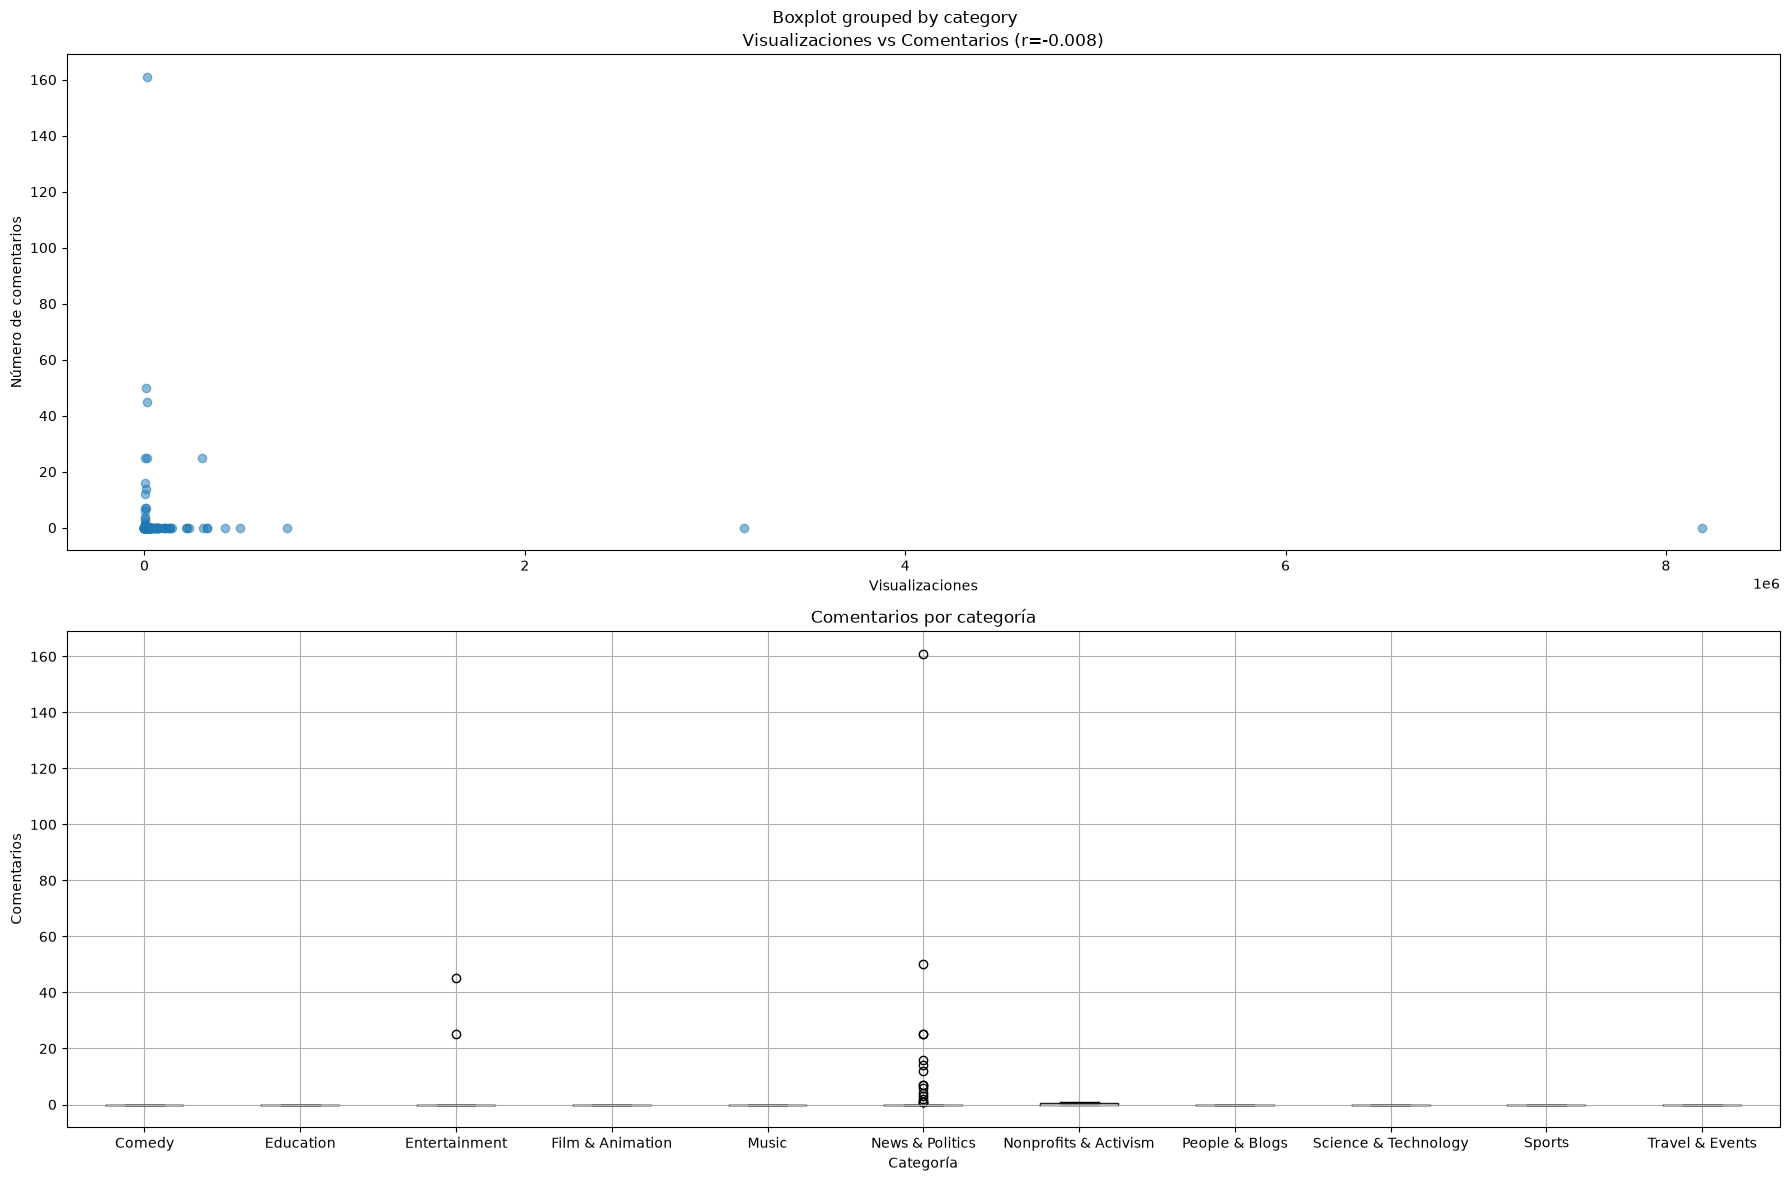

In [8]:
print("=== POPULARIDAD VS PARTICIPACION ===")

video_metrics = videos_clean[['video_id', 'title', 'view_count', 'category']].copy()
video_metrics['num_comentarios'] = video_metrics['video_id'].map(comms_vid).fillna(0)
video_metrics['num_autores'] = video_metrics['video_id'].map(auths_vid).fillna(0)

correlacion = video_metrics['view_count'].corr(video_metrics['num_comentarios'])
print(f"Correlacion visualizaciones vs comentarios: {correlacion:.2f}")

#graficas
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
#scatter
axes[0].scatter(video_metrics['view_count'], video_metrics['num_comentarios'], alpha=0.5)
axes[0].set_xlabel('Visualizaciones')
axes[0].set_ylabel('Número de comentarios')
axes[0].set_title(f'Visualizaciones vs Comentarios (r={correlacion:.3f})')

#boxplot cat.
video_metrics.boxplot(column='num_comentarios', by='category', ax=axes[1])
axes[1].set_title('Comentarios por categoría')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Comentarios')

plt.tight_layout()
plt.show()

=== NUBE DE PALABRAS ===


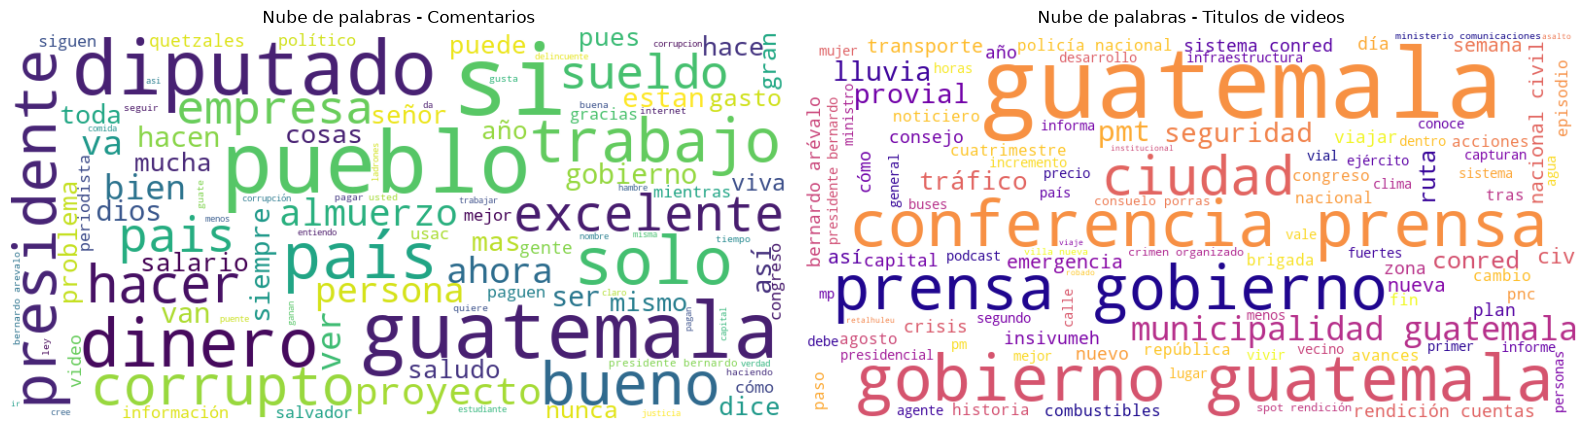

In [9]:
# Nube de palabras de comentarios
print("=== NUBE DE PALABRAS ===")
from wordcloud import WordCloud

# Nube de comentarios
texto_comentarios = ' '.join(comments_clean['text_limpio'].dropna())
if texto_comentarios:
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis',
                   max_words=100, max_font_size=100, random_state=42).generate(texto_comentarios)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(wc, interpolation='bilinear')
    axes[0].set_title('Nube de palabras - Comentarios')
    axes[0].axis('off')
    
    # Nube de titulos de videos
    texto_titulos = ' '.join(videos_clean['title_limpio'].dropna())
    if texto_titulos:
        wc_t = WordCloud(width=800, height=400, background_color='white', colormap='plasma',
                         max_words=100, max_font_size=100, random_state=42).generate(texto_titulos)
        axes[1].imshow(wc_t, interpolation='bilinear')
        axes[1].set_title('Nube de palabras - Titulos de videos')
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay texto limpio para generar nube de palabras")


=== PREGUNTAS ===

--- VIDEOS Y CANALES CON MAYOR PARTICIPACION ---
Video con mas comentarios:  Qué rico come tu diputado - n8iP75gIpmw (161 comentarios)
Canal con más comentarios: UCE4rsXcgDb6e1-a9iTbWzfg (256 comentarios)

--- AUDIENCIAS COMPARTIDAS ---
Autores que comentan en +1 video: 9 (2.71%)
Promedio de videos por autor activo: 2.22

--- AUTORES COMO PUENTES ---
Autores que comentan en +1 canal: 4
Top 5 autores puente:
  - @virgiliogarcia3039: comenta en 2 canales diferentes
  - @MarcosCarillo-b1r: comenta en 2 canales diferentes
  - @franciscoflores3120: comenta en 2 canales diferentes
  - @moisesvaldez4043: comenta en 2 canales diferentes

--- TEMAS Y SENTIMIENTOS ---
Top 10 palabras más frecuentes en comentarios:
  - si: 74
  - pueblo: 56
  - guatemala: 52
  - dinero: 34
  - solo: 33
  - presidente: 32
  - país: 31
  - trabajo: 30
  - diputados: 28
  - corruptos: 24

--- VISIBILIDAD VS PARTICIPACION ---
Top 5 videos por visualizaciones:
  - Los ALUCINANTES autobuses de Guatem

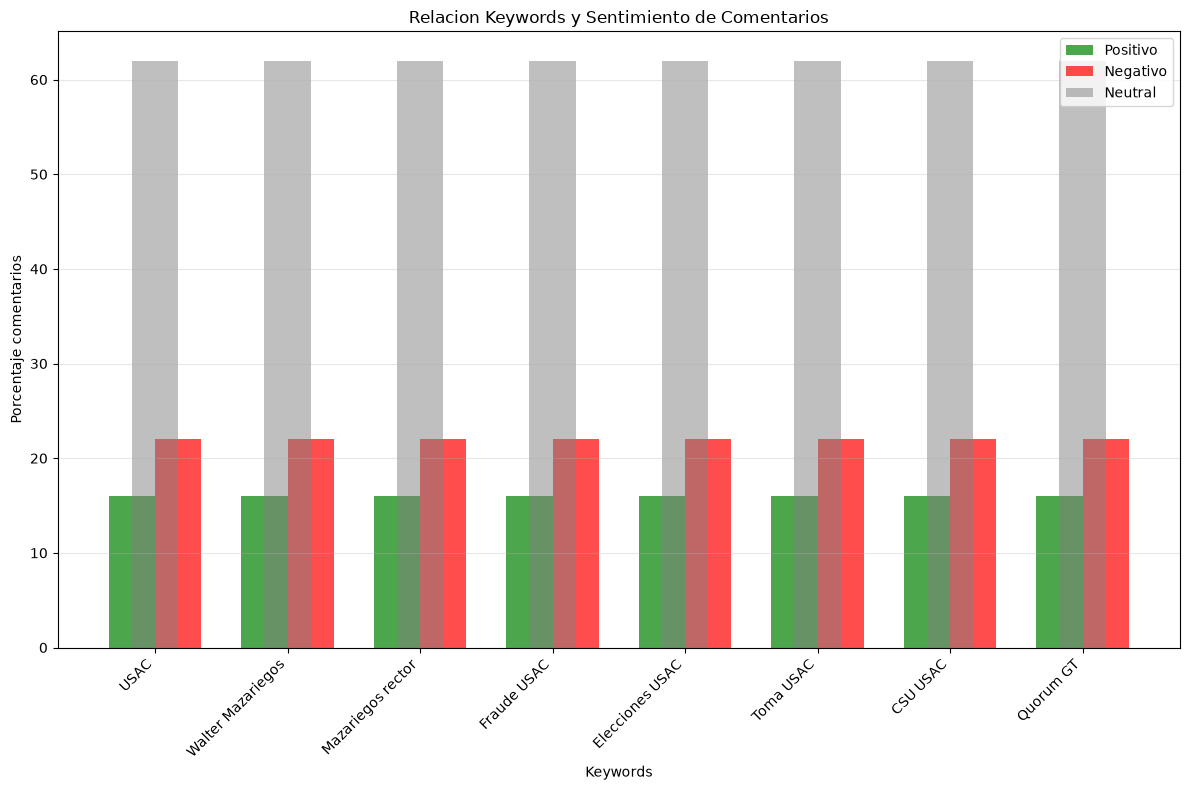

In [10]:
print("=== PREGUNTAS ===")

#¿Qué videos y canales concentran la mayor participación observada?
print("\n--- VIDEOS Y CANALES CON MAYOR PARTICIPACION ---")
comms_vid = comments_clean.groupby('video_id').size().sort_values(ascending=False)
video_top_id = comms_vid.index[0]
video_top_count = comms_vid.iloc[0]
video_top_title = videos_clean[videos_clean['video_id'] == video_top_id]['title'].iloc[0]

print(f"Video con mas comentarios:  {video_top_title} - {video_top_id} ({video_top_count} comentarios)")
#canal + comentarios
canal_top = comments_clean.groupby('channel_id').size().sort_values(ascending=False)
print(f"Canal con más comentarios: {canal_top.index[0]} ({canal_top.iloc[0]} comentarios)")

#¿Existen audiencias compartidas entre videos, canales o temas?
print("\n--- AUDIENCIAS COMPARTIDAS ---")
autores_multiples = comments_clean.groupby('author_channel_id')['video_id'].nunique()
autores_multiples = autores_multiples[autores_multiples > 1]
total_autores = comments_clean['author_channel_id'].nunique()
porcentaje = len(autores_multiples) / total_autores * 100

print(f"Autores que comentan en +1 video: {len(autores_multiples)} ({porcentaje:.2f}%)")
print(f"Promedio de videos por autor activo: {autores_multiples.mean():.2f}")

#¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían separados?
print("\n--- AUTORES COMO PUENTES ---")
autores_puente = comments_clean.groupby('author_channel_id')['channel_id'].nunique()
autores_puente = autores_puente[autores_puente > 1].sort_values(ascending=False)

print(f"Autores que comentan en +1 canal: {len(autores_puente)}")
print("Top 5 autores puente:")
for author, canales in autores_puente.head(5).items():
    nombre = comments_clean[comments_clean['author_channel_id'] == author]['author_name'].iloc[0]
    print(f"  - {nombre}: comenta en {canales} canales diferentes")


#¿Qué temas y sentimientos caracterizan a las principales comunidades de participación?
print("\n--- TEMAS Y SENTIMIENTOS ---")

todos_textos = ' '.join(comments_clean['text_limpio'].dropna())
palabras = todos_textos.split()
frecuencia = Counter(palabras)
print("Top 10 palabras más frecuentes en comentarios:")
for palabra, count in frecuencia.most_common(10):
    print(f"  - {palabra}: {count}")

#¿La visibilidad medida mediante visualizaciones coincide con la participación observada?
print("\n--- VISIBILIDAD VS PARTICIPACION ---")
top_visibilidad = videos_clean.nlargest(5, 'view_count')[['video_id', 'title', 'view_count']]

print("Top 5 videos por visualizaciones:")
for idx, row in top_visibilidad.iterrows():
    print(f"  - {row['title'][:50]}... ({row['view_count']:,} vistas)")

print("\nComparacion participacion:")
for idx, row in top_visibilidad.iterrows():
    video_id = row['video_id']
    comentarios = comms_vid.get(video_id, 0)
    print(f"  - {row['title'][:30]}... ({comentarios} comentarios)")

#¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura de los datos?
print("\n--- CONCLUSIONES LIMITADAS ---")
print("""
- Muestreo no probabilistico: los videos se seleccinarpn por medio de consultas eppecificas, al haber cierta separacion se da sesgo.
- Cobertura temporal limitada: 'pluboshed_time' es relativo
- Tamaño reudccion muestra: se alcanza un taoal de 293 videos y 49'6 anuthing
- Sesgo plat: Mayoria de los ususairos son espectadores pasivos, no muchos comentan., etc.
- Limitaciones en analisis text: Uso de tonos, inexactitud, no hay contextos.
- Sesgo Limitaciones: Los mas vistos no son necesariamente los mas comentados
""")

print("---- PREGUNTAS ADICIONALES ---")
#¿Los canales oficiales tienen más participación que los independientes?
print("1. Canales oficiales tienen mas participacion que independientes")
canales_oficiales = videos_clean[videos_clean['source_group'] == 'official_gov']['channel_id'].unique()
canales_no_oficiales = videos_clean[videos_clean['source_group'] != 'official_gov']['channel_id'].unique()

comentarios_oficiales = comments_clean[comments_clean['channel_id'].isin(canales_oficiales)]
comentarios_no_oficiales = comments_clean[comments_clean['channel_id'].isin(canales_no_oficiales)]

print(f"Canales oficiales: {len(canales_oficiales)}")
print(f"Canales no oficiales: {len(canales_no_oficiales)}")
print(f"\nComentarios en canales oficiales: {len(comentarios_oficiales)}")
print(f"Comentarios en canales no oficiales: {len(comentarios_no_oficiales)}")

prom_oficial = len(comentarios_oficiales) / len(canales_oficiales) if len(canales_oficiales) > 0 else 0
prom_no_oficial = len(comentarios_no_oficiales) / len(canales_no_oficiales) if len(canales_no_oficiales) > 0 else 0

print(f"\nPromedio de comentarios por canal oficial: {prom_oficial:.2f}")
print(f"Promedio de comentarios por canal no oficial: {prom_no_oficial:.2f}")
if prom_oficial > prom_no_oficial:
  print("...Los canales oficiales generan mas participación en promedio...")
else:
  print("Los canales no oficiales generan mas participacion en promedio")


print("2. Comentarios con más likes son más largos o más cortos?")
comments_clean['text_length'] = comments_clean['text_original'].str.len()

print("\nDistribucion de likes:")
print(comments_clean['like_count'].describe())

bins = [-1, 0, 1, 2, 10, float('inf')]
labels = ['Sin likes', '1 like', '2 likes', '3-10 likes', '>10 likes']

comments_clean['like_group'] = pd.cut(comments_clean['like_count'],
                                       bins=bins,
                                       labels=labels,
                                       right=True)

# Calcular longitud promedio por grupo
longitud_por_grupo = comments_clean.groupby('like_group')['text_length'].mean()
conteo_por_grupo = comments_clean.groupby('like_group').size()


print("3. Las palabras clave de los videos predicen el tono de los comentarios?")

import ast
videos_clean['keywords_list'] = videos_clean['keywords'].apply(ast.literal_eval)

#palabras + y -
positivas = ['bueno', 'bien', 'excelente', 'genial', 'gracias', 'mejor', 'gran', 'feliz', 'apoyo', 'gran', 'importante', 'valor', 'transparencia', 'honesto', 'esperanza']
negativas = ['malo', 'mal', 'corrupto', 'corruptos', 'pésimo', 'terrible', 'horrible', 'mentira', 'robo', 'triste', 'fracaso', 'decepcion', 'injusticia', 'traidor', 'engaño']

def sentimiento_texto(texto):
    if pd.isna(texto) or texto == '':
        return 'neutral'
    texto = str(texto).lower()
    pos = sum(1 for p in positivas if p in texto)
    neg = sum(1 for n in negativas if n in texto)
    if pos > neg:
        return 'positivo'
    elif neg > pos:
        return 'negativo'
    else:
        return 'neutral'

# Aplicar sentimiento a comentarios
comments_clean['sentimiento'] = comments_clean['text_limpio'].apply(sentimiento_texto)

print("\nDistribucion sentimientos en comentarios:")
print(comments_clean['sentimiento'].value_counts())


videos_sentimiento = videos_clean[['video_id', 'title', 'keywords_list']].copy()

sentimiento_por_video = comments_clean.groupby('video_id')['sentimiento'].value_counts().unstack(fill_value=0)
videos_sentimiento = videos_sentimiento.merge(sentimiento_por_video, on='video_id', how='left').fillna(0)

videos_sentimiento['total_comentarios'] = videos_sentimiento[['positivo', 'negativo', 'neutral']].sum(axis=1)

keyword_sentiment = {}

for idx, row in videos_sentimiento.iterrows():
    if row['total_comentarios'] > 0:
        for kw in row['keywords_list']:
            if kw not in keyword_sentiment:
                keyword_sentiment[kw] = {'pos': 0, 'neg': 0, 'total': 0, 'neutral': 0}
            keyword_sentiment[kw]['pos'] += row.get('positivo', 0)
            keyword_sentiment[kw]['neg'] += row.get('negativo', 0)
            keyword_sentiment[kw]['neutral'] += row.get('neutral', 0)
            keyword_sentiment[kw]['total'] += row['total_comentarios']

print("\nRelacion entre keywords y sentimiento:")
kw_sorted = sorted(keyword_sentiment.items(), key=lambda x: x[1]['total'], reverse=True)[:10]

print("\nTop 10 keywords con mas comentarios asociados:")
print(f"{'Keyword':<20} {'Total':>8} {'Positivo':>10} {'Negativo':>10} {'Neutral':>10}")
print("-" * 65)
for kw, datos in kw_sorted:
    if datos['total'] > 0:
        pos_pct = datos['pos'] / datos['total'] * 100
        neg_pct = datos['neg'] / datos['total'] * 100
        neu_pct = datos['neutral'] / datos['total'] * 100
        print(f"{kw:<20} {datos['total']:>8} {pos_pct:>9.1f}% {neg_pct:>9.1f}% {neu_pct:>9.1f}%")

fig, ax = plt.subplots(figsize=(12, 8))
kw_plot = kw_sorted[:8]
labels = [kw for kw, _ in kw_plot]
pos_values = [datos['pos']/datos['total']*100 for _, datos in kw_plot]
neg_values = [datos['neg']/datos['total']*100 for _, datos in kw_plot]
neutral_values = [datos['neutral']/datos['total']*100 for _, datos in kw_plot]

x = range(len(labels))
width = 0.35

ax.bar([i - width/2 for i in x], pos_values, width, label='Positivo', color='green', alpha=0.7)
ax.bar([i + width/2 for i in x], neg_values, width, label='Negativo', color='red', alpha=0.7)
# Neutral como fondo
ax.bar(x, neutral_values, width, label='Neutral', color='gray', alpha=0.5, bottom=0)

ax.set_xlabel('Keywords')
ax.set_ylabel('Porcentaje comentarios')
ax.set_title('Relacion Keywords y Sentimiento de Comentarios')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Construcción de la red bipartita autor-video

=== CONSTRUCCION RED BIPARTITA ===

--- RED BIPARTITA NO DIRIGIDA ---
Autores unicos: 332
Videos unicos: 19
Total nodos: 351


Nodos agregados: 351

--- AGREGANDO ARISTAS CON PESO ---
Aristas agregadas: 343

--- TABLAS DE NODOS Y ARISTAS ---

TABLA NODOS (351 nodos)
Fragmento:
                                                  id   tipo  \
0  (UCdFlugHJJa4l3YqWuNRmvXw, {'tipo': 'autor', '...  autor   
1  (UCvl1tzQeBeGy6efPTRJXSCw, {'tipo': 'autor', '...  autor   
2  (UCRAquv8el-tQ30bN7MlmySQ, {'tipo': 'autor', '...  autor   
3  (UCkbsS_3D-pvg1iHOld9uvIg, {'tipo': 'autor', '...  autor   
4  (UCOLHH4ZpMxPYF-Q6e6wvn5A, {'tipo': 'autor', '...  autor   
5  (UCi2KiZq63sRq8Mfbcp-MelQ, {'tipo': 'autor', '...  autor   
6  (UCXl30Y_upRqbti52fmjK4YA, {'tipo': 'autor', '...  autor   
7  (UCRelkU8JiZBytTzebJxaa-w, {'tipo': 'autor', '...  autor   
8  (UCgLurCo-e019HGODcjXHWCw, {'tipo': 'autor', '...  autor   
9  (UCDIMztpVm7G27qBuiWuT6oQ, {'tipo': 'autor', '...  autor   

                 nombre                 handle  num_comentarios  num_videos  \
0    @MarcosCarillo-b1r    /@MarcosCarillo-b1r                2         2.0 

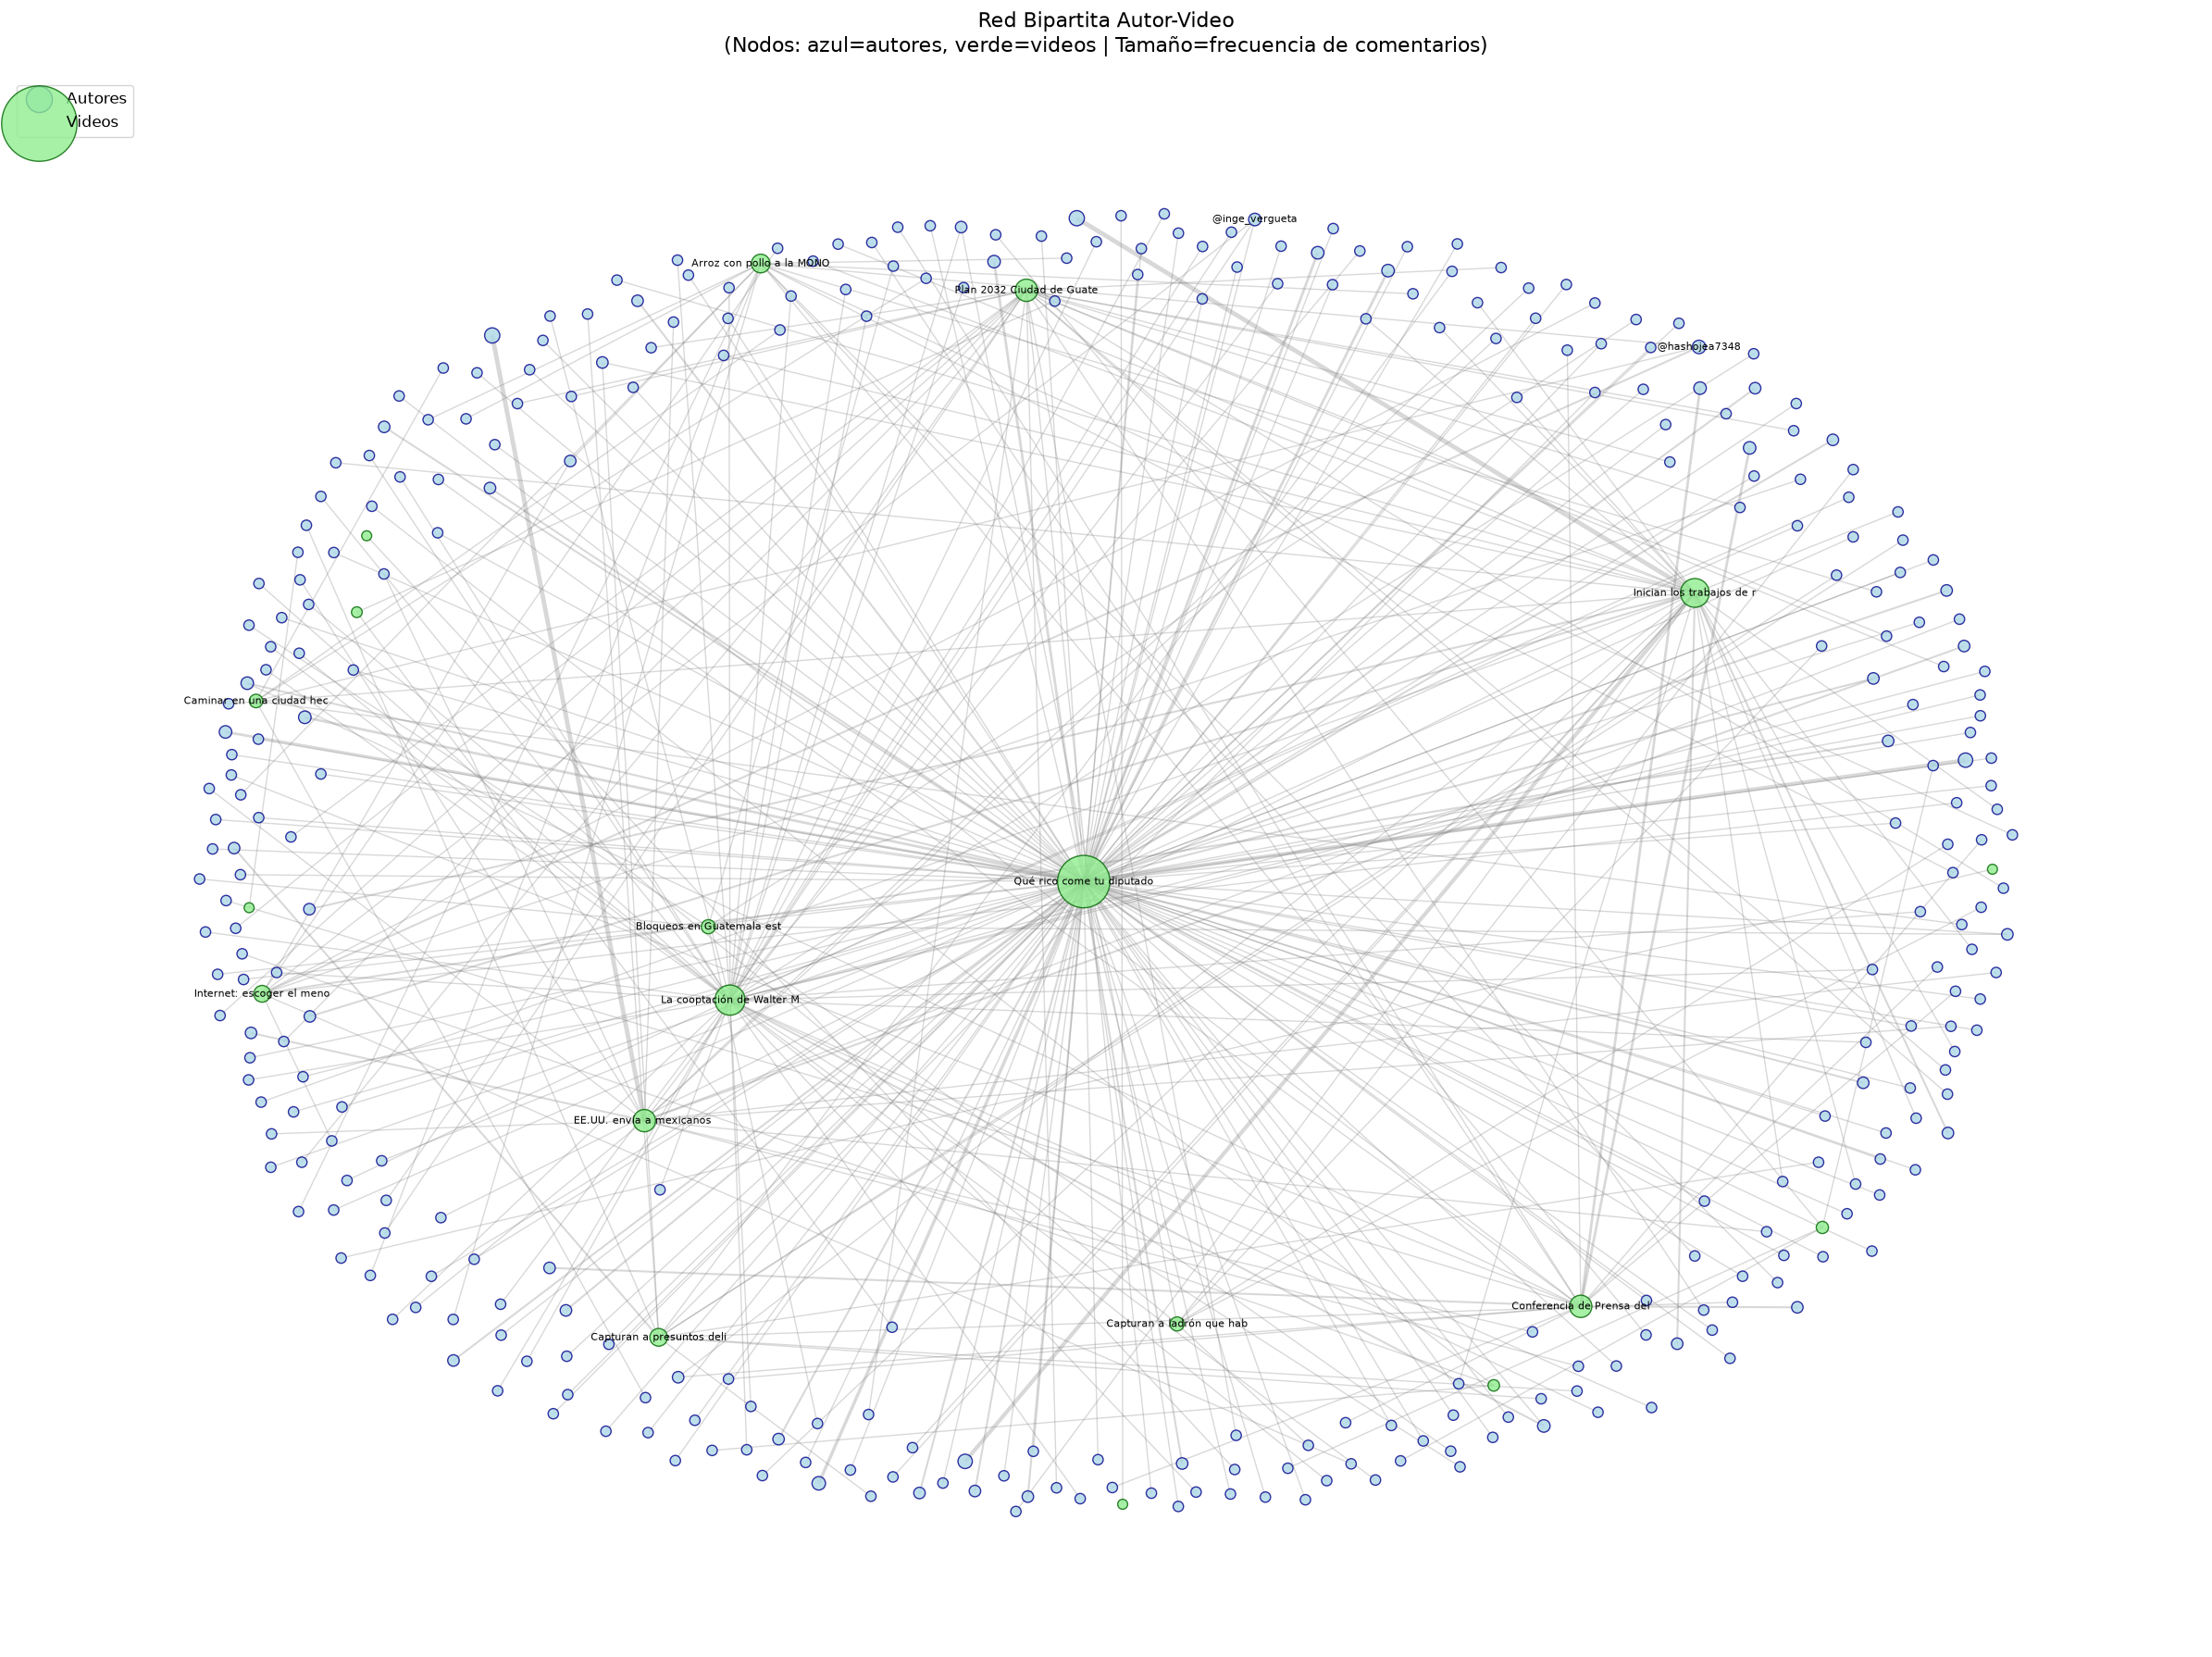

In [11]:
print("=== CONSTRUCCION RED BIPARTITA ===")
import networkx as nx

print("\n--- RED BIPARTITA NO DIRIGIDA ---")

G = nx.Graph()

autores = comments_clean['author_channel_id'].unique().tolist()
videos_nodes = comments_clean['video_id'].unique().tolist()

print(f"Autores unicos: {len(autores)}")
print(f"Videos unicos: {len(videos_nodes)}")
print(f"Total nodos: {len(autores) + len(videos_nodes)}")

#nodos autores
for author in autores:
    author_info = comments_clean[comments_clean['author_channel_id'] == author].iloc[0]
    num_comentarios = len(comments_clean[comments_clean['author_channel_id'] == author])
    num_videos = comments_clean[comments_clean['author_channel_id'] == author]['video_id'].nunique()
    G.add_node(author,
               tipo='autor',
               nombre=author_info['author_name'],
               handle=author_info.get('author_handle', ''),
               num_comentarios=num_comentarios,
               num_videos=num_videos)

#nodos vids
for video in videos_nodes:
    video_info = videos_clean[videos_clean['video_id'] == video]
    if len(video_info) > 0:
        video_info = video_info.iloc[0]
        num_comentarios_video = len(comments_clean[comments_clean['video_id'] == video])
        num_autores_video = comments_clean[comments_clean['video_id'] == video]['author_channel_id'].nunique()
        G.add_node(video,
                   tipo='video',
                   titulo=video_info['title'],
                   categoria=video_info['category'],
                   channel_id=video_info['channel_id'],
                   view_count=video_info['view_count'],
                   num_comentarios=num_comentarios_video,
                   num_autores=num_autores_video)

print(f"Nodos agregados: {G.number_of_nodes()}")

#peso artistaas
print("\n--- AGREGANDO ARISTAS CON PESO ---")

for author in autores:
    comments_autor = comments_clean[comments_clean['author_channel_id'] == author]
    for video in comments_autor['video_id'].unique():
        peso = len(comments_autor[comments_autor['video_id'] == video])
        G.add_edge(author, video, peso=peso)

print(f"Aristas agregadas: {G.number_of_edges()}")

print("\n--- TABLAS DE NODOS Y ARISTAS ---")

#tabla nodos
nodes_data = []
for node in G.nodes(data=True):
    node_dict = {'id': node}
    node_dict.update(node[1])
    nodes_data.append(node_dict)

nodes_df = pd.DataFrame(nodes_data)
print(f"\nTABLA NODOS ({len(nodes_df)} nodos)")
print("Fragmento:")
print(nodes_df.head(10))

nodes_df.to_csv('red_nodos.csv', index=False)
print("\nTabla de nodos guardada como 'red_nodos.csv'")

#tabla aristas
edges_data = []
for u, v, data in G.edges(data=True):
    edges_data.append({
        'source': u,
        'target': v,
        'peso': data.get('peso', 1)
    })

edges_df = pd.DataFrame(edges_data)
print(f"\nTABLA ARISTAS ({len(edges_df)} aristas)")
print("Fragmento:")
print(edges_df.head(10))

edges_df.to_csv('red_aristas.csv', index=False)
print("\nTabla de aristas guardada como 'red_aristas.csv'")

print("\n--- VISUALIZACION RED ---")

node_colors = []
node_sizes = []
for node in G.nodes():
    if G.nodes[node]['tipo'] == 'autor':
        node_colors.append('lightblue')
        node_sizes.append(50 + G.nodes[node]['num_comentarios'] * 15)
    else:  # video
        node_colors.append('lightgreen')
        node_sizes.append(50 + G.nodes[node]['num_comentarios'] * 10)

pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)

fig, ax = plt.subplots(figsize=(24, 18))

edge_weights = [data.get('peso', 1) for u, v, data in G.edges(data=True)]
max_weight = max(edge_weights) if edge_weights else 1
edge_widths = [0.5 + (w / max_weight) * 3 for w in edge_weights]

nx.draw_networkx_edges(G, pos,
                       width=edge_widths,
                       alpha=0.3,
                       edge_color='gray')
#nodos autores
autores_list = [n for n in G.nodes() if G.nodes[n]['tipo'] == 'autor']
nx.draw_networkx_nodes(G, pos,
                       nodelist=autores_list,
                       node_color='lightblue',
                       node_size=[50 + G.nodes[n]['num_comentarios'] * 15 for n in autores_list],
                       label='Autores',
                       alpha=0.8,
                       edgecolors='darkblue',
                       linewidths=1)

#nodo vid
videos_list = [n for n in G.nodes() if G.nodes[n]['tipo'] == 'video']
nx.draw_networkx_nodes(G, pos,
                       nodelist=videos_list,
                       node_color='lightgreen',
                       node_size=[50 + G.nodes[n]['num_comentarios'] * 10 for n in videos_list],
                       label='Videos',
                       alpha=0.8,
                       edgecolors='darkgreen',
                       linewidths=1)

labels = {}
for node in G.nodes():
    if G.nodes[node]['tipo'] == 'autor':
        if G.degree(node) > 2:
            labels[node] = G.nodes[node]['nombre'][:15]
    else:
        if G.degree(node) > 5:
            labels[node] = G.nodes[node]['titulo'][:25]

nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title('Red Bipartita Autor-Video\n(Nodos: azul=autores, verde=videos | Tamaño=frecuencia de comentarios)',
          fontsize=16, pad=20)
plt.legend(loc='upper left', fontsize=12, markerscale=2)
plt.axis('off')
plt.tight_layout()
plt.show()

### 4.5 Significado de la arista

Cada arista en esta red representa que **un autor publico al menos un comentario en un video**. El peso de la arista indica cuantos comentarios publico ese autor en ese video especifico.

**Que NO significa la arista:**
- No significa que el autor sea "amigo" del canal o del video
- No significa que haya interactuado con otros comentaristas
- No significa aprobacion o desacuerdo con el contenido
- No representa una conversacion (reply_count no identifica autores de respuestas)

**Que SI significa:**
- Coincidencia de espacio: el autor y el video compartieron un momento en la plataforma
- Participacion observada: el autor decidio comentar en ese video especifico
- Relacion autor-video: es una relacion de un modo a otro (bipartita), no entre pares del mismo tipo

La red resultante describe patrones de participacion, no redes sociales ni comunidades de interaccion.